In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight,compute_spherical_coordinates, sphere_from_toroid
from grid_cells.bat_hd_system import sphere_to_toroid
from grid_cells.plot_tools import angular_error
import os
PLOTS_DIR = "../plots"

In [2]:
T = 100
dt = 0.5e-3
bat_flight = generate_bat_flight(
    T=T,
    dt=dt,
)

100%|██████████| 199999/199999 [00:13<00:00, 14428.67it/s]


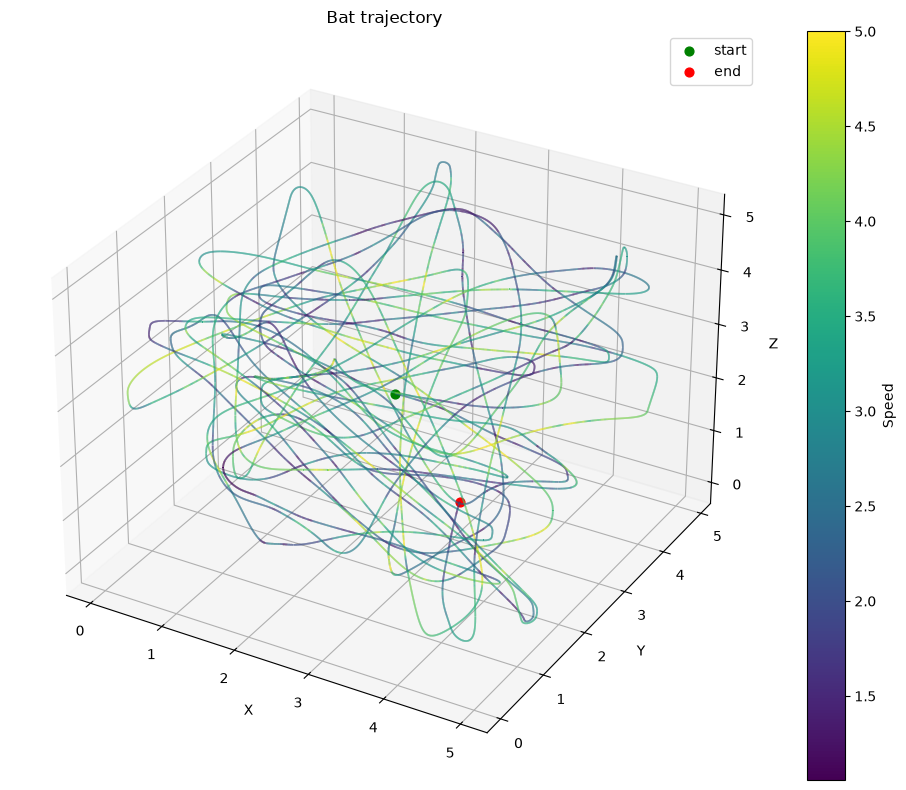

In [3]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

inverting = bat_flight["inverted"]
speed = bat_flight["speed"]
pos = bat_flight["pos"]
inverted = pos[inverting]
upright = pos[~inverting]


segments = np.stack([pos[:-1], pos[1:]], axis=1)
norm = plt.Normalize(speed[:-1].min(), speed[:-1].max())
colors = plt.cm.viridis(norm(speed[:-1]))

ax.add_collection3d(Line3DCollection(segments, colors=colors, linewidths=1.2))

sm = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array(speed)
fig.colorbar(sm, ax=ax, label="Speed")
# Add legend entries for the trajectory color states
ax.scatter(pos[0, 0], pos[0, 1], pos[0, 2], color="green", s=40, label="start")
ax.scatter(pos[-1, 0], pos[-1, 1], pos[-1, 2], color="red", s=40, label="end")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Bat trajectory")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "bat_trajectory.png"), dpi=300)

(array([14901., 22409., 26479., 29909., 26300., 24697., 21927., 17414.,
        10375.,  5589.]),
 array([1.05782673, 1.45204406, 1.84626139, 2.24047871, 2.63469604,
        3.02891337, 3.42313069, 3.81734802, 4.21156535, 4.60578267,
        5.        ]),
 <BarContainer object of 10 artists>)

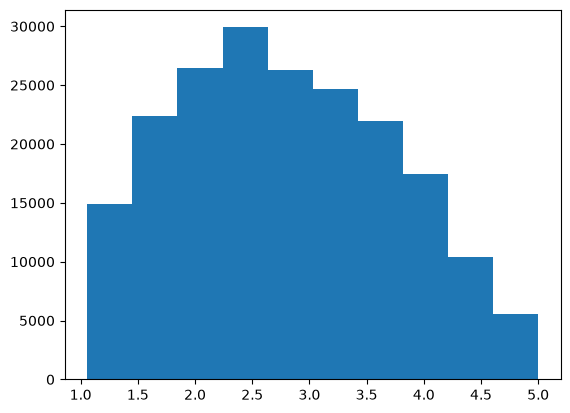

In [4]:
plt.hist(np.linalg.norm(bat_flight["vel"], axis=-1))